<a href="https://colab.research.google.com/github/adhikarisamundra/Aggression-Game-Analysis/blob/main/Grid_Map_Strategic_Opening_Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Aggression: Strategic Opening Analyzer ---
Enter grid rows (m): 3
Enter grid columns (n): 3

Analyzing opening moves for a 3x3 grid...
  Analyzed cell (0,0)... Score: 2
  Analyzed cell (0,1)... Score: 2
  Analyzed cell (0,2)... Score: 2
  Analyzed cell (1,0)... Score: 2
  Analyzed cell (1,1)... Score: 2
  Analyzed cell (1,2)... Score: 2
  Analyzed cell (2,0)... Score: 2
  Analyzed cell (2,1)... Score: 2
  Analyzed cell (2,2)... Score: 2

Generating heatmap image...


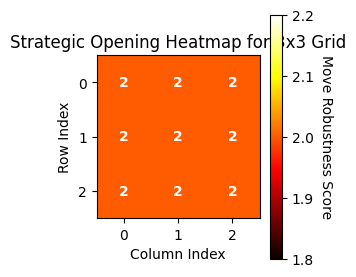


Heatmap saved as 'strategic_heatmap.png'

Total analysis took 2585.2157 seconds.


In [ ]:
import sys
import time
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

# --- (This section is copied from the Game Solver for its core logic) ---

# --- Game State Representation ---
class GameState:
    def __init__(self, m, n, p1_troops, p2_troops, grid, turn_player):
        self.m, self.n = m, n
        self.p1_troops, self.p2_troops = p1_troops, p2_troops
        self.grid = grid
        self.turn_player = turn_player
        self.initiative_winner = self._check_initiative()
    def _check_initiative(self):
        if self.p1_troops == 0 and self.p2_troops > 0: return 'P1'
        if self.p2_troops == 0 and self.p1_troops > 0: return 'P2'
        return None
    def is_game_over(self):
        board_full = all(cell is not None for row in self.grid for cell in row)
        both_out_of_troops = self.p1_troops == 0 and self.p2_troops == 0
        return board_full or both_out_of_troops
    def canonical_form(self):
        return (tuple(map(tuple, self.grid)), self.p1_troops, self.p2_troops, self.turn_player)
    def get_possible_moves(self):
        if self.is_game_over(): return []
        moves, troops_opts = [], [1]
        current_troops = self.p1_troops if self.turn_player == 'P1' else self.p2_troops
        if current_troops > 1:
            if current_troops <= 5: troops_opts.extend(range(2, current_troops + 1))
            else: troops_opts.extend([current_troops // 2, current_troops])
        empty_cells = [(r, c) for r in range(self.m) for c in range(self.n) if self.grid[r][c] is None]
        for pos in empty_cells:
            for k in troops_opts:
                if k <= current_troops: moves.append({'k': k, 'pos': pos})
        return moves
    def apply_move(self, move):
        new_grid = deepcopy(self.grid)
        r, c = move['pos']
        k = move['k']
        new_p1, new_p2 = self.p1_troops, self.p2_troops
        if self.turn_player == 'P1': new_p1 -= k
        else: new_p2 -= k
        new_grid[r][c] = (self.turn_player, k)
        return GameState(self.m, self.n, new_p1, new_p2, new_grid, 'P2' if self.turn_player == 'P1' else 'P1')

# --- Minimax Solver Logic ---
memoization_cache = {}
def evaluate_final_state(state):
    p1_cells = sum(1 for row in state.grid for cell in row if cell and cell[0] == 'P1')
    p2_cells = sum(1 for row in state.grid for cell in row if cell and cell[0] == 'P2')
    if p1_cells > p2_cells: return 1
    if p2_cells > p1_cells: return -1
    initiative = state.initiative_winner or 'P1'
    return 1 if initiative == 'P1' else -1
def minimax(state, is_maximizing_player):
    canonical = state.canonical_form()
    if canonical in memoization_cache: return memoization_cache[canonical]
    if state.is_game_over(): return evaluate_final_state(state)
    possible_moves = state.get_possible_moves()
    if not possible_moves:
        state.turn_player = 'P2' if state.turn_player == 'P1' else 'P1'
        return minimax(state, not is_maximizing_player)
    if is_maximizing_player:
        best_val = -float('inf')
        for move in possible_moves: best_val = max(best_val, minimax(state.apply_move(move), False))
    else:
        best_val = float('inf')
        for move in possible_moves: best_val = min(best_val, minimax(state.apply_move(move), True))
    memoization_cache[canonical] = best_val
    return best_val

# --- (End of copied logic) ---


# --- New Heatmap Image Generation Logic ---

def generate_image_heatmap(heatmap_data, m, n):
    """
    Generates and saves a graphical heatmap image using Matplotlib.
    """
    print("\nGenerating heatmap image...")
    data = np.array(heatmap_data)

    fig, ax = plt.subplots(figsize=(n, m))
    im = ax.imshow(data, cmap='hot', interpolation='nearest')

    # Add a color bar legend
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Move Robustness Score", rotation=-90, va="bottom")

    # Set up the grid ticks and labels
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(m))
    ax.set_xticklabels(np.arange(n))
    ax.set_yticklabels(np.arange(m))
    ax.set_xlabel("Column Index")
    ax.set_ylabel("Row Index")

    # Loop over data dimensions and create text annotations.
    for i in range(m):
        for j in range(n):
            text_color = "black" if data[i, j] < (data.max() / 2) else "white"
            text = ax.text(j, i, data[i, j],
                           ha="center", va="center", color=text_color, weight="bold")

    ax.set_title(f"Strategic Opening Heatmap for {m}x{n} Grid")
    fig.tight_layout()

    # Save the figure and show it
    plt.savefig("strategic_heatmap.png")
    plt.show()
    print("\nHeatmap saved as 'strategic_heatmap.png'")


def analyze_openings():
    """
    Analyzes all possible opening moves for P1 on a given grid to generate
    a heatmap of the most strategically sound positions.
    """
    print("--- Aggression: Strategic Opening Analyzer ---")

    try:
        rows = int(input("Enter grid rows (m): "))
        cols = int(input("Enter grid columns (n): "))

        if rows * cols > 9:
            print("\n\033[93mWarning: Grid size is larger than 9 cells.\033[0m")
            print("This analysis is extremely demanding and will likely take a very long time.")
            consent = input("Are you absolutely sure you want to proceed? (yes/no): ").lower()
            if not consent.startswith('y'):
                print("Analysis cancelled by user.")
                return

        heatmap_data = [[0 for _ in range(cols)] for _ in range(rows)]
        total_troops = rows * cols

        opening_troop_options = [1]
        if total_troops > 1:
            opening_troop_options.append(total_troops // 2)
            opening_troop_options.append(total_troops)

        print(f"\nAnalyzing opening moves for a {rows}x{cols} grid...")
        start_time = time.time()

        for r in range(rows):
            for c in range(cols):
                cell_score = 0
                for k in opening_troop_options:
                    global memoization_cache
                    memoization_cache = {}
                    initial_grid = [[None for _ in range(cols)] for _ in range(rows)]
                    initial_grid[r][c] = ('P1', k)
                    p1_troops_after_move = total_troops - k
                    state_after_opening = GameState(rows, cols, p1_troops_after_move, total_troops, initial_grid, 'P2')

                    outcome = minimax(state_after_opening, False)
                    if outcome == 1:
                        cell_score += 1

                heatmap_data[r][c] = cell_score
                print(f"  Analyzed cell ({r},{c})... Score: {cell_score}")

        end_time = time.time()

        generate_image_heatmap(heatmap_data, rows, cols)

        print(f"\nTotal analysis took {end_time - start_time:.4f} seconds.")

    except (ValueError, EOFError):
        print("\nAnalysis exited.")
    except Exception as e:
        print(f"\nAn unexpected error occurred: {e}")

if __name__ == "__main__":
    analyze_openings()
